# Onboarding: one-directional adjacency prediction

Given two jigsaw pieces A and B from the same puzzle, predict whether **B sits directly to the right of A**.
To solve the entire puzzle, we repeatedly ask this question, rotating pieces and swapping the order as needed to determine 
top/bottom adjacency and whether B is to the left of A.

What you'll do:
1. Load preprocessed images and cut them into 10x10 jigsaw puzzles
2. Turn the question "is B right of A?" into one image of both pieces that a model can look at
3. Build a training set with both horizontal and (rotated) vertical neighbors, with negatives
   drawn from the *same* puzzle
4. Score pairs with a no-learning baseline
5. Write a small CNN and train it with a hand-written training loop
6. Evaluate by **ranking**, not just accuracy, and compare against the baseline

**Before running:** from the repo root, run `uv sync`, `uv run python scripts/download.py` and
`uv run python scripts/preprocess.py`, then select the `.venv` kernel for this notebook.

Everything here runs on a CPU. The whole notebook takes about 20 minutes; slow cells are marked.

In [1]:
import csv
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from torch import nn

from interlock.data_collection.cutting import COLS, PAD, ROWS, cut

# find the repo root from wherever the notebook is running, then the data folder
REPO_ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
DATA_DIR = Path(os.environ.get("INTERLOCK_DATA_DIR", REPO_ROOT / "data"))
PROCESSED_DIR = DATA_DIR / "processed"

torch.manual_seed(0)
rng = np.random.default_rng(0)

# use a GPU if there is one, fall back to cpu
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


## 1. Load images and cut puzzles

Data comes from Imagenette, a subset of Imagenet. `scripts/preprocess.py` crops images into 400x400 PNGs and a `manifest.csv` listing them. Data is split into a train and val set.
**Seed rule:** puzzle `i` in a split is always cut with `seed=i`, so that the model sees different puzzle configurations and we can reproduce a training set.

In [2]:
with open(PROCESSED_DIR / "manifest.csv") as manifest_file:
    manifest = list(csv.DictReader(manifest_file))
train_rows = [row for row in manifest if row["split"] == "train"]
val_rows = [row for row in manifest if row["split"] == "val"]
print(f"{len(train_rows)} train images, {len(val_rows)} val images")


def load_image(row):
    """(400, 400, 3) uint8 array for one manifest row."""
    return np.array(Image.open(PROCESSED_DIR / row["path"]))


def load_puzzle(rows, index):
    """Cut image `index` of a split into a puzzle, using the seed rule."""
    return cut(load_image(rows[index]), seed=index)

1500 train images, 300 val images


`cut` returns three arrays (N = 100 pieces):
- `pieces`: `(N, B, B, 3)`. Each piece sits in a box of its 40x40 grid cell plus `PAD` pixels on
  every side, so tabs fit. Pixels that aren't part of the piece are 0.
- `masks`: `(N, B, B)`. True where a pixel of the box belongs to the piece.
- `positions`: `(N, 2)`. The piece's correct `(x, y)` slot in the grid; `x` = column, `y` = row.

pieces (100, 72, 72, 3) uint8 | masks (100, 72, 72) | positions (100, 2)


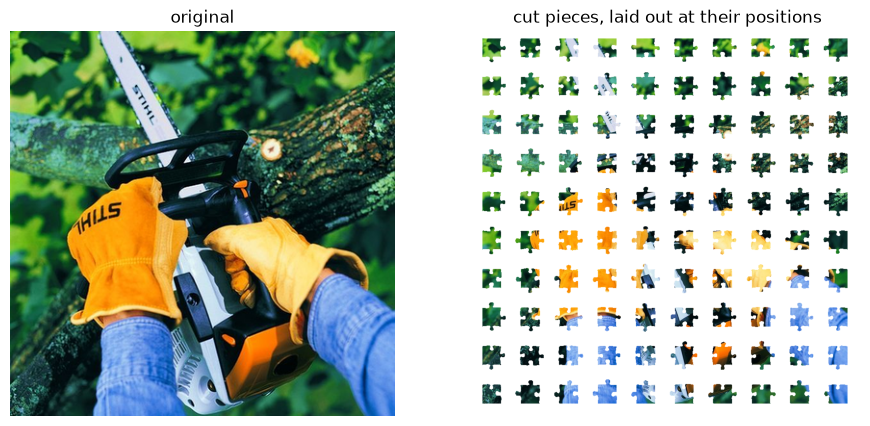

In [3]:
image = load_image(train_rows[0])
pieces, masks, positions = load_puzzle(train_rows, 0)
print("pieces", pieces.shape, pieces.dtype, "| masks", masks.shape, "| positions", positions.shape)

IMAGE_SIZE = image.shape[0]
CELL = IMAGE_SIZE // COLS  # 40: side of one grid cell
BOX = pieces.shape[1]  # 72: side of a piece's box (CELL + 2 * PAD)

fig, (ax_image, ax_pieces) = plt.subplots(1, 2, figsize=(11, 5))
ax_image.imshow(image)
ax_image.set_title("original")
for piece, mask, (x, y) in zip(pieces, masks, positions):
    rgba = np.dstack([piece, mask.astype(np.uint8) * 255])  # transparent outside the piece
    left, top = x * BOX * 1.15, y * BOX * 1.15
    ax_pieces.imshow(rgba, extent=(left, left + BOX, top + BOX, top))
ax_pieces.set_xlim(0, COLS * BOX * 1.15)
ax_pieces.set_ylim(ROWS * BOX * 1.15, 0)
ax_pieces.set_title("cut pieces, laid out at their positions")
for ax in (ax_image, ax_pieces):
    ax.axis("off")
plt.show()

## 2. Turning a pair into an image

To ask "is B right of A?", place B exactly where A's right neighbor would go: one cell (40 px) to
the right of A. If B is to the right of A, we shouldn't see any discontinuity.

Note: this is a fundamentally different way of approaching this problem. Here, the model sees how two pieces
look when put together and determines whether they are a match rather than how two pieces look separately and determining 
how they fit together, if at all. 

The model sees the **whole pair**, i.e., the input is the two pieces joined together. Alongside the colors we keep an `owners` map saying which piece
each pixel came from (0 = neither, 1 = A, 2 = B); the baseline in section 4 uses it.

In [4]:
PAIR_HEIGHT, PAIR_WIDTH = BOX, CELL + BOX  # 72 x 112: A's box at column 0, B's box one cell to the right


def make_pair_images(pieces, masks, left_ids, right_ids):
    """Images of piece right_ids[k] placed as the right neighbor of piece left_ids[k].

    Returns images (n, PAIR_HEIGHT, PAIR_WIDTH, 3) uint8 and owners (same shape without the color
    channel): 0 = empty, 1 = left piece, 2 = right piece. Where pieces overlap, the right piece is
    drawn on top.
    """
    num_pairs = len(left_ids)
    images = np.zeros((num_pairs, PAIR_HEIGHT, PAIR_WIDTH, 3), dtype=np.uint8)
    owners = np.zeros((num_pairs, PAIR_HEIGHT, PAIR_WIDTH), dtype=np.int8)

    for piece_ids, first_column, owner in [(left_ids, 0, 1), (right_ids, CELL, 2)]:
        columns = slice(first_column, first_column + BOX)  # where this piece's box sits on the canvas
        piece_mask = masks[piece_ids]  # (n, BOX, BOX)
        images[:, :, columns][piece_mask] = pieces[piece_ids][piece_mask]
        owners[:, :, columns][piece_mask] = owner
    return images, owners

Pieces are returned in grid order, and `positions` tells us where each belongs. Let's look up a
piece's true right neighbor and compare it with a random wrong piece.

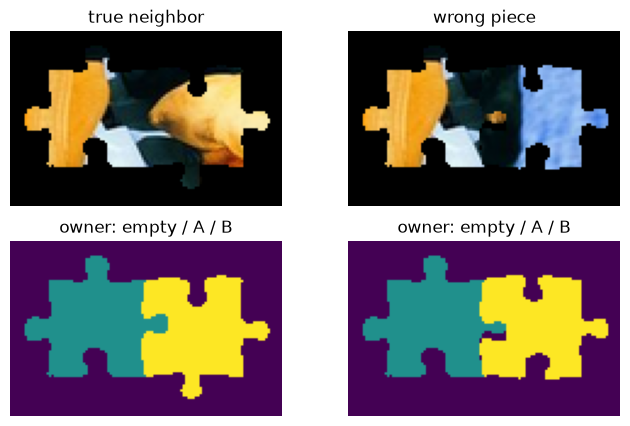

In [5]:
position_to_id = {tuple(position): piece_id for piece_id, position in enumerate(positions)}
left_id = position_to_id[(4, 5)]
true_right_id = position_to_id[(5, 5)]
wrong_right_id = position_to_id[(2, 8)]

pair_images, owners = make_pair_images(pieces, masks, [left_id, left_id], [true_right_id, wrong_right_id])
fig, axes = plt.subplots(2, 2, figsize=(8, 5))
for column, title in enumerate(["true neighbor", "wrong piece"]):
    axes[0, column].imshow(pair_images[column])
    axes[0, column].set_title(title)
    axes[1, column].imshow(owners[column], cmap="viridis", vmin=0, vmax=2)
    axes[1, column].set_title("owner: empty / A / B")
for ax in axes.flat:
    ax.axis("off")
plt.show()

### Vertical neighbors: rotate, then ask the same question

Assembling a puzzle needs all four directions, not just "right of". We don't need four models:
- **left of** is "right of" with A and B swapped
- **below** becomes "right of" after rotating both pieces 90 degrees counter-clockwise: the top of an
  image moves to the left and the bottom to the right, so "A above B" turns into "A left of B"
- **above** is "below" with A and B swapped

So one "is B right of A?" model covers every direction. `orient` rotates a whole puzzle's pieces and
masks so that a chosen direction becomes "right"; the boxes are square, so `make_pair_images` works
unchanged. Training on rotated vertical pairs as well as horizontal ones doubles the pairs we can
get from each puzzle and teaches the model to judge seams in any orientation.

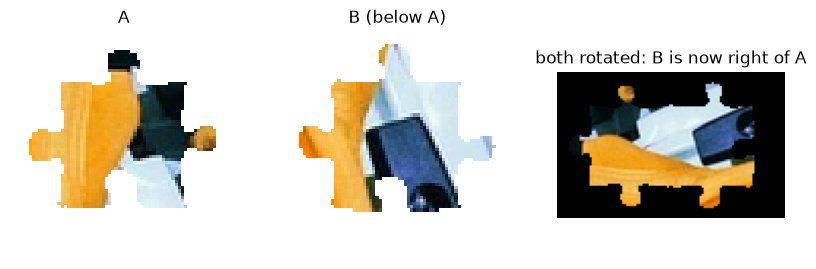

In [6]:
DIRECTIONS = ["right", "below"]
DIRECTION_OFFSETS = {"right": (1, 0), "below": (0, 1)}  # (dx, dy) from a piece to its neighbor


def neighbor_ids(positions, direction):
    """Dict: piece id -> id of its neighbor in `direction` (pieces on the far edge have none)."""
    dx, dy = DIRECTION_OFFSETS[direction]
    position_to_id = {tuple(position): piece_id for piece_id, position in enumerate(positions)}
    return {
        piece_id: position_to_id[(x + dx, y + dy)]
        for piece_id, (x, y) in enumerate(positions)
        if (x + dx, y + dy) in position_to_id
    }


def orient(pieces, masks, direction):
    """Rotate pieces and masks so that `direction` becomes "right" (counter-clockwise for "below")."""
    if direction == "right":
        return pieces, masks
    return np.rot90(pieces, k=1, axes=(1, 2)), np.rot90(masks, k=1, axes=(1, 2))


# the piece below our example piece, before and after rotating
true_below_id = neighbor_ids(positions, "below")[left_id]
rotated_pieces, rotated_masks = orient(pieces, masks, "below")
pair_images, owners = make_pair_images(rotated_pieces, rotated_masks, [left_id], [true_below_id])

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
axes[0].imshow(np.dstack([pieces[left_id], masks[left_id].astype(np.uint8) * 255]))
axes[0].set_title("A")
axes[1].imshow(np.dstack([pieces[true_below_id], masks[true_below_id].astype(np.uint8) * 255]))
axes[1].set_title("B (below A)")
axes[2].imshow(pair_images[0])
axes[2].set_title("both rotated: B is now right of A")
for ax in axes:
    ax.axis("off")
plt.show()

## 3. Building a training set

Positives: (A, its true right neighbor). Negatives: (A, some other piece from the same puzzle). Pieces from a different image are trivially easy to reject because the colors are
completely different; telling apart pieces of the same picture is the actual challenge.

For each puzzle and each direction ("right" and "below", rotated so both look like "right"), we
take `PAIRS_PER_PUZZLE` positives and the same number of negatives, so the classes are balanced.
We also record each pair's direction, so we can later check whether the model does worse on either.

*Slow cell:* cutting a puzzle takes ~0.1 s, so 1,000 puzzles take a couple of minutes. The pair images
take about 1 GB of memory; lower `NUM_TRAIN_PUZZLES` if that's too much.

In [7]:
PAIRS_PER_PUZZLE = 10  # positives per puzzle per direction (plus as many negatives)
NUM_TRAIN_PUZZLES = 1000
NUM_VAL_PUZZLES = 200


def sample_pairs(positions, num_pairs, rng, direction):
    """num_pairs positive and num_pairs negative (A, B) pairs for one direction, plus labels."""
    neighbors = neighbor_ids(positions, direction)
    left_ids = rng.choice(list(neighbors), size=2 * num_pairs, replace=False)

    right_ids = []
    for left_id in left_ids[:num_pairs]:  # positives
        right_ids.append(neighbors[left_id])
    for left_id in left_ids[num_pairs:]:  # negatives: any other piece of the same puzzle
        wrong_choices = [piece_id for piece_id in range(len(positions)) if piece_id not in (left_id, neighbors[left_id])]
        right_ids.append(rng.choice(wrong_choices))

    labels = np.array([1] * num_pairs + [0] * num_pairs, dtype=np.float32)
    return left_ids, np.array(right_ids), labels


def build_pair_dataset(rows, num_puzzles, rng):
    """Pair images, owners, labels and direction indices for sampled pairs from a split's first puzzles."""
    all_images, all_owners, all_labels, all_directions = [], [], [], []
    start_time = time.time()
    for puzzle_index in range(num_puzzles):
        pieces, masks, positions = load_puzzle(rows, puzzle_index)
        for direction_index, direction in enumerate(DIRECTIONS):
            oriented_pieces, oriented_masks = orient(pieces, masks, direction)
            left_ids, right_ids, labels = sample_pairs(positions, PAIRS_PER_PUZZLE, rng, direction)
            pair_images, owners = make_pair_images(oriented_pieces, oriented_masks, left_ids, right_ids)
            all_images.append(pair_images)
            all_owners.append(owners)
            all_labels.append(labels)
            all_directions.append(np.full(len(labels), direction_index))
        if (puzzle_index + 1) % 250 == 0:
            print(f"  {puzzle_index + 1}/{num_puzzles} puzzles ({time.time() - start_time:.0f}s)")
    return tuple(np.concatenate(parts) for parts in (all_images, all_owners, all_labels, all_directions))


print("building train pairs")
train_images, train_owners, train_labels, train_directions = build_pair_dataset(train_rows, NUM_TRAIN_PUZZLES, rng)
print("building val pairs")
val_images, val_owners, val_labels, val_directions = build_pair_dataset(val_rows, NUM_VAL_PUZZLES, rng)
print("train", train_images.shape, "val", val_images.shape, "| positive fraction", train_labels.mean())
print(f"memory: {(train_images.nbytes + val_images.nbytes) / 1e9:.1f} GB of pair images")

building train pairs
  250/1000 puzzles (31s)
  500/1000 puzzles (58s)
  750/1000 puzzles (85s)
  1000/1000 puzzles (113s)
building val pairs
train (40000, 72, 112, 3) val (8000, 72, 112, 3) | positive fraction 0.5
memory: 1.2 GB of pair images


## 4. A baseline with no learning

Before training anything, we will establish a baseline using an entirely deterministic approach. Intuitively, if two pieces are neighboring, the pixels that are on the boundary between them should be similar in value. We define **seam dissimilarity** as the average squared color difference between touching pixels where one belongs to A and the other to B. Lower means a better fit.

We will compare CNN results to this baseline.

In [8]:
def seam_dissimilarity(pair_images, owners):
    """Mean squared color difference across the A/B boundary for each pair image (lower = better fit)."""
    # A and B can only touch where both boxes exist (columns CELL..BOX), so skip the rest for speed
    overlap = slice(CELL - 1, BOX + 1)
    pair_images, owners = pair_images[:, :, overlap], owners[:, :, overlap]
    pixels = pair_images.astype(np.float32)
    total = np.zeros(len(pair_images))
    count = np.zeros(len(pair_images))
    # compare each pixel with its neighbor below (axis 1) and to the right (axis 2)
    for axis in (1, 2):
        first = [slice(None)] * 3
        second = [slice(None)] * 3
        first[axis], second[axis] = slice(None, -1), slice(1, None)
        owner_first, owner_second = owners[tuple(first)], owners[tuple(second)]
        touching = ((owner_first == 1) & (owner_second == 2)) | ((owner_first == 2) & (owner_second == 1))
        squared_diff = ((pixels[tuple(first)] - pixels[tuple(second)]) ** 2).sum(axis=-1)
        total += (squared_diff * touching).sum(axis=(1, 2))
        count += touching.sum(axis=(1, 2))
    return np.where(count > 0, total / np.maximum(count, 1), np.inf)


baseline_scores = seam_dissimilarity(val_images, val_owners)
for direction_index, direction in enumerate(DIRECTIONS):
    for label, name in [(1, "true neighbors"), (0, "wrong pieces")]:
        selected = (val_labels == label) & (val_directions == direction_index)
        print(f"{direction:>5} | median dissimilarity, {name}: {np.median(baseline_scores[selected]):.0f}")

right | median dissimilarity, true neighbors: 310
right | median dissimilarity, wrong pieces: 16365
below | median dissimilarity, true neighbors: 350
below | median dissimilarity, wrong pieces: 16645


Note the big gap in median dissimilarity between true neighbors and false neighbors. This suggests that this metric can effectively distinguish between adjacent and non-adjacent pieces!

## 5. Evaluating by ranking

A solver asks: *for this piece, which of the other 99 pieces is its right neighbor?* 

So for each piece A that has a right neighbor, we score **every** other piece as a candidate and
record the true neighbor's **rank** (1 = best). We report:
- **top-1 accuracy**: how often the true neighbor ranks first
- **mean rank**: on average, how far down the list it is (1 is perfect, ~50 is random)

`ranking_eval` takes any scoring function where **higher = more likely the neighbor**, so the same
code evaluates the baseline and the CNN. We run it separately for "right" and "below" neighbors.

*Slow cell:* each puzzle means 90 x 99 = 8,910 pair images, so this takes a minute or two.

In [9]:
NUM_RANKING_PUZZLES = 8


def ranking_eval(score_pairs, rows, num_puzzles, direction):
    """Top-1 accuracy and mean rank of each piece's true neighbor in `direction` among all other pieces."""
    ranks = []
    for puzzle_index in range(num_puzzles):
        pieces, masks, positions = load_puzzle(rows, puzzle_index)
        pieces, masks = orient(pieces, masks, direction)
        for left_id, true_right_id in neighbor_ids(positions, direction).items():
            candidate_ids = np.array([piece_id for piece_id in range(len(pieces)) if piece_id != left_id])
            pair_images, owners = make_pair_images(pieces, masks, np.full(len(candidate_ids), left_id), candidate_ids)
            scores = score_pairs(pair_images, owners)
            true_score = scores[candidate_ids == true_right_id][0]
            ranks.append(1 + np.sum(scores > true_score))
    ranks = np.array(ranks)
    return {"top1": round(float(np.mean(ranks == 1)), 3), "mean_rank": round(float(ranks.mean()), 2)}


def ranking_eval_all(score_pairs, rows, num_puzzles):
    """ranking_eval for every direction."""
    return {direction: ranking_eval(score_pairs, rows, num_puzzles, direction) for direction in DIRECTIONS}


def baseline_score_pairs(pair_images, owners):
    return -seam_dissimilarity(pair_images, owners)  # negate: higher = better fit


baseline_ranking = ranking_eval_all(baseline_score_pairs, val_rows, NUM_RANKING_PUZZLES)
print("baseline:", baseline_ranking)

baseline: {'right': {'top1': 0.825, 'mean_rank': 2.38}, 'below': {'top1': 0.812, 'mean_rank': 2.04}}


This method works well :) Our goal is to try and beat that using a deep learning approach.

## 6. Adjacency CNN

The model sees a whole pair image (3 x 72 x 112) and outputs one number: positive means
"B is the right neighbor", negative means "it isn't".

In [10]:
def to_tensor(pair_images):
    return torch.from_numpy(pair_images).permute(0, 3, 1, 2).float().div(255).to(device)


class AdjacencyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # kept small so it trains in minutes on a laptop CPU
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),  # 72x112 -> 36x56
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),  # -> 18x28
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),  # -> 9x14
        )
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(64 * 9 * 14, 64), nn.ReLU(), nn.Linear(64, 1))

    def forward(self, x):
        return self.head(self.features(x)).squeeze(1)  # (n,) logits


cnn = AdjacencyCNN().to(device)
print(f"{sum(p.numel() for p in cnn.parameters()):,} parameters")

539,809 parameters


### The training loop

Written out by hand so every step is visible:
1. shuffle the training pairs each epoch
2. take a batch, run the model, compute the loss
3. `zero_grad` -> `backward` -> `step` to update the weights

The loss is **binary cross-entropy on logits** (`BCEWithLogitsLoss`), the standard loss for yes/no
classification. It applies the sigmoid internally, which is more numerically stable than doing it
yourself.

*Slow cell:* about 5 minutes on a laptop CPU, plus a couple of minutes for the ranking evaluation below.

epoch 1/3: loss 0.061 (112s)
epoch 2/3: loss 0.035 (97s)
epoch 3/3: loss 0.024 (91s)


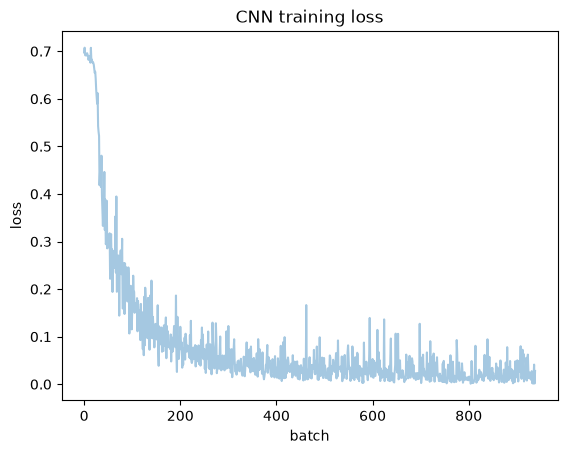

In [11]:
def train(model, pair_images, labels, epochs=3, batch_size=128, learning_rate=1e-3):
    """Train model on (pair_images, labels) and return the loss of every batch."""
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.BCEWithLogitsLoss()
    batch_losses = []
    model.train()
    for epoch in range(epochs):
        order = rng.permutation(len(pair_images))
        start_time = time.time()
        for batch_start in range(0, len(order), batch_size):
            batch = order[batch_start : batch_start + batch_size]
            logits = model(to_tensor(pair_images[batch]))
            loss = loss_fn(logits, torch.from_numpy(labels[batch]).to(device))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        recent_loss = np.mean(batch_losses[-100:])
        print(f"epoch {epoch + 1}/{epochs}: loss {recent_loss:.3f} ({time.time() - start_time:.0f}s)")
    return batch_losses


cnn_losses = train(cnn, train_images, train_labels)
plt.plot(cnn_losses, alpha=0.4)
plt.xlabel("batch")
plt.ylabel("loss")
plt.title("CNN training loss")
plt.show()

## 7. How good is it?

First, plain accuracy on the balanced val pairs: does the model say "neighbor" for positives and
"not neighbor" for negatives? Then the ranking evaluation from section 5.

In [12]:
@torch.no_grad()
def predict_logits(model, pair_images, batch_size=512):
    model.eval()
    return np.concatenate([
        model(to_tensor(pair_images[start : start + batch_size])).cpu().numpy()
        for start in range(0, len(pair_images), batch_size)
    ])


def balanced_accuracy(model):
    """Accuracy on the balanced val pairs, separately for each direction."""
    correct = (predict_logits(model, val_images) > 0) == (val_labels == 1)
    return {direction: round(float(correct[val_directions == index].mean()), 3) for index, direction in enumerate(DIRECTIONS)}


def model_score_pairs(model):
    """Wrap a model as a scoring function for ranking_eval."""
    return lambda pair_images, owners: predict_logits(model, pair_images)


print("CNN balanced accuracy on val pairs:", balanced_accuracy(cnn))
cnn_ranking = ranking_eval_all(model_score_pairs(cnn), val_rows, NUM_RANKING_PUZZLES)
print("CNN:     ", cnn_ranking)
print("baseline:", baseline_ranking)

CNN balanced accuracy on val pairs: {'right': 0.992, 'below': 0.991}
CNN:      {'right': {'top1': 0.94, 'mean_rank': 1.17}, 'below': {'top1': 0.942, 'mean_rank': 1.1}}
baseline: {'right': {'top1': 0.825, 'mean_rank': 2.38}, 'below': {'top1': 0.812, 'mean_rank': 2.04}}


**Compare the balanced accuracy with the top-1 ranking accuracy.** Balanced accuracy checks average accuracy when comparing pairs. Ranking accuracy checks how high up the true neighbor ranks when one piece is compared after all others — true neighbors succeed only if they beat all non-neighbors, which is why this is a stricter metric.

Also compare "right" with "below". The model was trained on both, but vertical pairs only ever reach
it rotated (sky on the left, for example). 

## 8. Takeaways

This classifier needs a forward pass for every (A, B) pair: 9,900 per puzzle here, and the count grows with the square of the number of pieces. A contrastive model instead learns one **embedding** per piece edge, trained so that matching edges end
up close together. Each piece is processed once, and comparing candidates is a cheap dot product.

Also, this does show that there are several different ways we can feed a model information. It'll be interesting to see what kind of representation best equips the model to learn what we want it to.